**Data Cleaning:**

In [67]:
# Import libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [68]:
# Load dataset
df = pd.read_csv("amazonreviews.tsv", sep='\t')

In [69]:
df.shape

(10000, 2)

In [70]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [71]:
# 1. Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [72]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [73]:
#checking missing values
df.isnull().sum()

,0
label,0
review,0


In [74]:
import re
import spacy
# Load SpaCy model
nlp = spacy.load("en_core_web_sm")

In [75]:
# Data cleaning function
# - Lowercasing
# - Remove special characters
# - Remove stopwords
# - Remove punctuation
# - Remove digits
# - Lemmatization

In [76]:
def data_clean(text):

    # Convert text to lowercase
    text = text.lower()

    # Keep only words
    text = ' '.join(re.findall(r'\w+', text))

    # Process text using SpaCy
    doc = nlp(text)

    cleaned_data = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_digit
        and not token.is_currency
        and not token.is_space
    ]

    # Return cleaned text as string
    return ' '.join(cleaned_data)


In [77]:
# Apply preprocessing
df['clean_review'] = df['review'].apply(data_clean)

In [78]:
# View sample output
df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stun non gamer sound track beautiful paint sen...
1,The best soundtrack ever to anything.: I'm rea...,good soundtrack m read lot review say good gam...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hear ve play game know...


**Exploratory Analysis:**

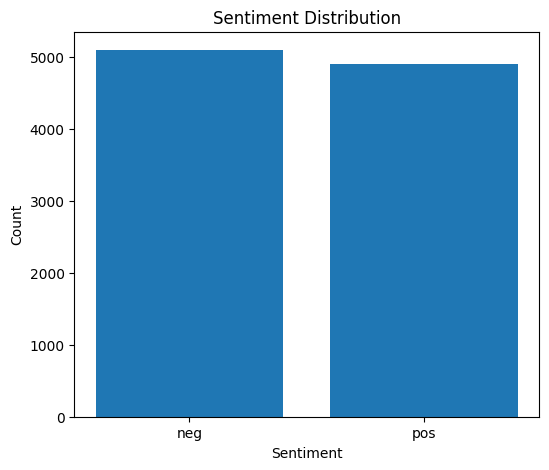

In [79]:
# Sentiment Distribution
sentiment_count = df['label'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()


In [80]:
# Separate positive and negative data
positive_reviews = " ".join(df[df['label']=='pos']['clean_review'])
negative_reviews = " ".join(df[df['label']=='neg']['clean_review'])

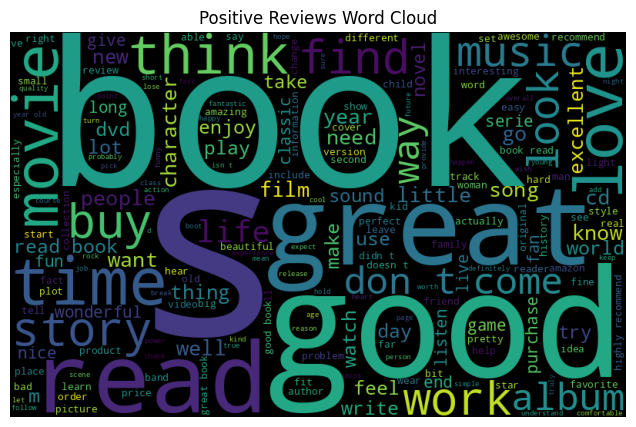

In [81]:
# Positive Word Cloud
wordcloud_pos = WordCloud(width=800,height=500).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()


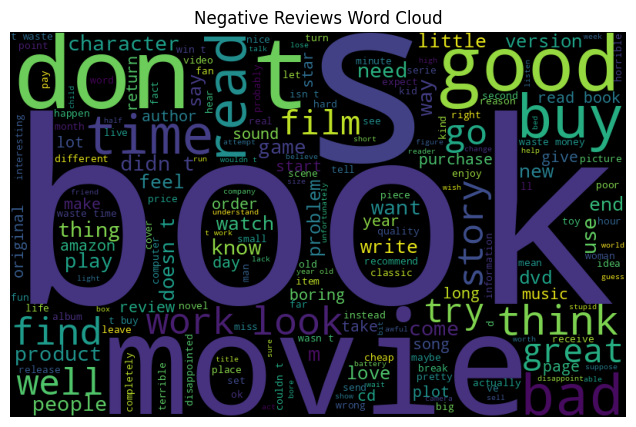

In [82]:
# 3. Negative Word Cloud
wordcloud_neg = WordCloud(width=800,height=500).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [83]:
# Most Common Positive Words
positive_words = positive_reviews.split()
top_positive = Counter(positive_words).most_common(10)
print("Top Positive Words")
print(top_positive)

Top Positive Words
[('book', 3934), ('s', 3150), ('good', 2452), ('great', 2233), ('read', 2000), ('t', 1869), ('like', 1514), ('movie', 1327), ('love', 1323), ('time', 1190)]


In [84]:
# Most Common Negative Words
negative_words = negative_reviews.split()
top_negative = Counter(negative_words).most_common(10)
print("Top Negative Words")
print(top_negative)

Top Negative Words
[('book', 3757), ('t', 3596), ('s', 2916), ('movie', 1784), ('like', 1696), ('read', 1624), ('buy', 1537), ('good', 1433), ('time', 1321), ('bad', 1291)]


**Model Development:**

In [85]:
# Model Development
# TF-IDF + Logistic Regression, SVM
# Word2Vec + Logistic Regression, SVM

In [86]:
!pip install gensim

In [87]:
import numpy as np
from gensim.models import Word2Vec
import gensim.downloader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [88]:
# Features and Target
x = df['clean_review']
y = df['label']

In [89]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=50,stratify=y)

In [90]:
# TF-IDF Feature Extraction
tfidf_v = TfidfVectorizer(ngram_range=(1,1),max_features=5000)
x_train_tfidf = tfidf_v.fit_transform(x_train)
x_test_tfidf = tfidf_v.transform(x_test)

In [91]:
# Logistic Regression with TF-IDF

lr_tfidf = LogisticRegression(max_iter=1000)

lr_tfidf.fit(x_train_tfidf, y_train)

pred_lr_tfidf = lr_tfidf.predict(x_test_tfidf)

print("Logistic Regression + TF-IDF")
print("Accuracy:",
      accuracy_score(y_test, pred_lr_tfidf))

print(classification_report(y_test,pred_lr_tfidf))

Logistic Regression + TF-IDF
Accuracy: 0.842
              precision    recall  f1-score   support

         neg       0.84      0.85      0.85      1019
         pos       0.84      0.83      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [92]:
# SVM with TF-IDF
svm_tfidf = SVC()

svm_tfidf.fit(x_train_tfidf, y_train)

pred_svm_tfidf = svm_tfidf.predict(x_test_tfidf)

print("\nSVM + TF-IDF")
print("Accuracy:",accuracy_score(y_test, pred_svm_tfidf))

print(classification_report(y_test,pred_svm_tfidf))



SVM + TF-IDF
Accuracy: 0.85
              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [93]:
# Word2Vec Feature Extraction

# Convert reviews into tokens
train_data = [text.split() for text in x_train]
test_data = [text.split() for text in x_test]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=train_data,
    min_count=2,
    window=5,
    epochs=10,
    sg=0,
    vector_size=100
)

In [94]:
# Function to convert review to vector
def review_vector(review):
    vectors=[]
    for word in review:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors)==0:
        return np.zeros(100)
    return np.mean(vectors,axis=0)

In [95]:
# Create review vectors
x_train_w2v = np.array(
    [review_vector(text)
     for text in train_data])

x_test_w2v = np.array(
    [review_vector(text)
     for text in test_data])

In [96]:
# Logistic Regression + Word2Vec
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(x_train_w2v,y_train)
pred_lr_w2v = lr_w2v.predict(x_test_w2v)
print("\nLogistic Regression + Word2Vec")
print("Accuracy:",accuracy_score(y_test,pred_lr_w2v))
print(classification_report(y_test,pred_lr_w2v))


Logistic Regression + Word2Vec
Accuracy: 0.8025
              precision    recall  f1-score   support

         neg       0.79      0.83      0.81      1019
         pos       0.81      0.78      0.79       981

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



In [97]:
# SVM + Word2Vec
svm_w2v = SVC()
svm_w2v.fit(x_train_w2v,y_train)
pred_svm_w2v = svm_w2v.predict(x_test_w2v)
print("\nSVM + Word2Vec")
print("Accuracy:",accuracy_score(y_test,pred_svm_w2v))
print(classification_report(y_test,pred_svm_w2v))


SVM + Word2Vec
Accuracy: 0.793
              precision    recall  f1-score   support

         neg       0.78      0.82      0.80      1019
         pos       0.80      0.76      0.78       981

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



**Validation:**

In [98]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report)
from sklearn.model_selection import cross_val_score

In [99]:
# Store models and predictions
models = {

    "TF-IDF + Logistic Regression":
        (lr_tfidf, x_test_tfidf, pred_lr_tfidf, x_train_tfidf),

    "TF-IDF + SVM":
        (svm_tfidf, x_test_tfidf, pred_svm_tfidf, x_train_tfidf),

    "Word2Vec + Logistic Regression":
        (lr_w2v, x_test_w2v, pred_lr_w2v, x_train_w2v),

    "Word2Vec + SVM":
        (svm_w2v, x_test_w2v, pred_svm_w2v, x_train_w2v)

}

In [100]:
# Evaluate each model

for name, (model, x_test_data, pred, x_train_data) in models.items():
    print("="*50)
    print(name)
    # Accuracy
    accuracy = accuracy_score(y_test,pred)
    print("\nAccuracy:",accuracy)
    # F1 Score
    f1 = f1_score(y_test,pred,pos_label='pos')
    print("F1 Score:",f1)
    # Classification Report
    print("\nClassification Report")
    print(classification_report(y_test,pred))
    # Cross Validation
    cv_scores = cross_val_score(model,x_train_data,y_train,cv=5,scoring='accuracy')
    print("\nCross Validation Scores:")
    print(cv_scores)
    print("Mean CV Accuracy:",cv_scores.mean())
    print("="*50)

TF-IDF + Logistic Regression

Accuracy: 0.842
F1 Score: 0.8376156217882836

Classification Report
              precision    recall  f1-score   support

         neg       0.84      0.85      0.85      1019
         pos       0.84      0.83      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000


Cross Validation Scores:
[0.840625 0.840625 0.849375 0.846875 0.854375]
Mean CV Accuracy: 0.8463749999999999
TF-IDF + SVM

Accuracy: 0.85
F1 Score: 0.8469387755102041

Classification Report
              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Cross Validation Scores:
[0.84     0.84625  0.838125 0.8